In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("/content/superstore.csv")

In [3]:
print(data.head())
print(data.info())

  Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0      1  CA-2017-152156   11/8/2017  11/11/2017    Second Class    CG-12520   
1      2  CA-2017-152156   11/8/2017  11/11/2017    Second Class    CG-12520   
2      3  CA-2017-138688   6/12/2017   6/16/2017    Second Class    DV-13045   
3      4  US-2016-108966  10/11/2016  10/18/2016  Standard Class    SO-20335   
4      5  US-2016-108966  10/11/2016  10/18/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0     42420.0   South  FUR

In [4]:
data["Order Date"] = pd.to_datetime(data["Order Date"])
print(data.isnull().sum())

Row ID             0
Order ID           0
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64


In [5]:
data["Month"] = data["Order Date"].dt.month
data["Year"] = data["Order Date"].dt.year

In [6]:
total_revenue = data["Sales"].sum()
print("Total Revenue:", round(total_revenue, 2))

Total Revenue: 2297200.86


In [7]:
avg_order_value = data.groupby("Order ID")["Sales"].sum().mean()
print("Average Order Value:", round(avg_order_value, 2))

Average Order Value: 458.07


In [8]:
top_regions = data.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print(top_regions)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


In [9]:
top_products = data.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

/tmp/ipykernel_4695/1191327317.py:6: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


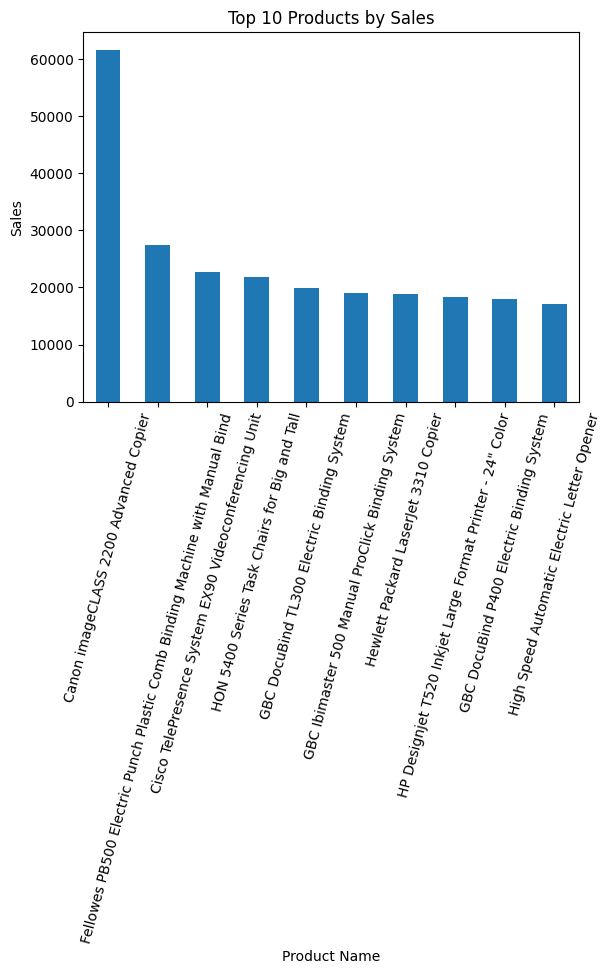

In [10]:
plt.figure()
top_products.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.ylabel("Sales")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [11]:
monthly_sales = data.groupby("Month")["Sales"].sum()

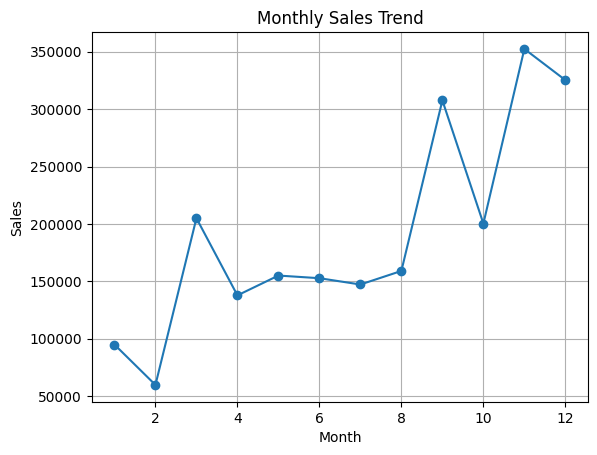

In [12]:
plt.figure()
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

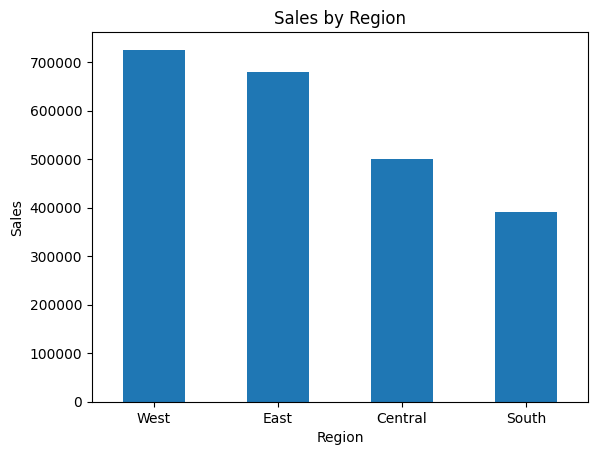

In [13]:
plt.figure()
top_regions.plot(kind="bar")
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

In [14]:
sales_trend = data.groupby("Order Date")["Sales"].sum()

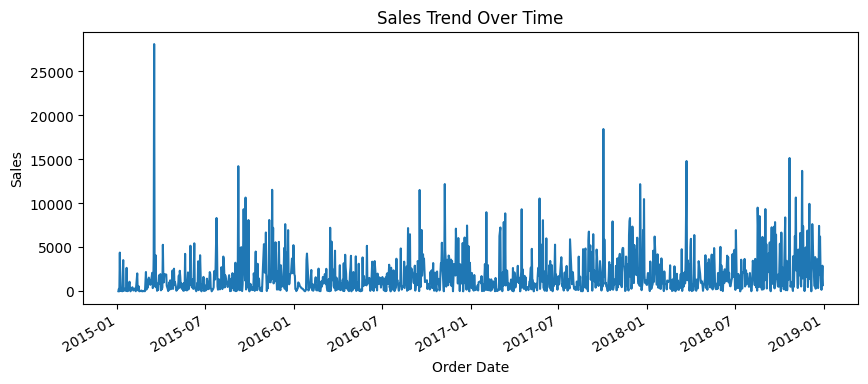

In [15]:
plt.figure(figsize=(10,4))
sales_trend.plot()
plt.title("Sales Trend Over Time")
plt.ylabel("Sales")
plt.show()

In [16]:
!pip install fpdf2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 13.8 MB/s eta 0:00:00


In [17]:
from fpdf import FPDF

pdf = FPDF()
pdf.add_page()

pdf.set_font("Arial", "B", 14)
pdf.cell(0, 10, "Sales Analysis Summary", ln=True)

pdf.set_font("Arial", size=11)
pdf.multi_cell(0, 8, f"""
Total Revenue: {round(total_revenue,2)}
Average Order Value: {round(avg_order_value,2)}

Top Region:
{top_regions.idxmax()}

Key Insights:
- Strong seasonal trends
- Top products dominate revenue
- Regional sales imbalance

Recommendations:
- Focus on high-demand products
- Increase marketing during peak months
- Expand in top regions
""")

pdf.output("Sales_Analysis_Summary.pdf")

/tmp/ipykernel_4695/2996744695.py:6: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", "B", 14)
/tmp/ipykernel_4695/2996744695.py:7: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, "Sales Analysis Summary", ln=True)
/tmp/ipykernel_4695/2996744695.py:9: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", size=11)
